In [1]:
#Q1- Load the file. Report shape, dtypes, and missing counts per column.
import pandas as pd
import numpy as np

# Load the raw CSV
df = pd.read_csv("suvidha_loan_predictions_raw.csv")

# Shape
print("Shape:", df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing counts
print("\nMissing Counts:")
print(df.isna().sum())

Shape: (2400, 9)

Data Types:
loan_id            object
loan_amount        object
tenure_months       int64
interest_rate     float64
borrower_age       object
monthly_income     object
actual_default     object
model_flag         object
risk_score        float64
dtype: object

Missing Counts:
loan_id            0
loan_amount        0
tenure_months      0
interest_rate      0
borrower_age      38
monthly_income    36
actual_default    40
model_flag        22
risk_score         0
dtype: int64


The raw export contains 2,400 pilot loans, and the missing-value counts identify which fields require cleaning before evaluating the model.

In [2]:
#Q2:- Clean loan_amount to numeric (strip currency text and commas).
# Keep a copy of the raw values for comparison
df["loan_amount_raw"] = df["loan_amount"]

# Remove currency text, commas, spaces, then convert to numeric
df["loan_amount"] = (
    df["loan_amount"]
    .astype("string")
    .str.replace(r"Rs\s*", "", regex=True)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["loan_amount"] = pd.to_numeric(df["loan_amount"], errors="coerce")

# Check the result
print(df[["loan_amount_raw", "loan_amount"]].head(10))

print("\nloan_amount dtype:")
print(df["loan_amount"].dtype)

print("\nNew missing values after conversion:")
print(df["loan_amount"].isna().sum())

  loan_amount_raw  loan_amount
0     60777.81992  60777.81992
1     258399.8923  258399.8923
2     114338.0322  114338.0322
3     60919.14875  60919.14875
4     104225.1581  104225.1581
5      116603.653   116603.653
6     87640.16155  87640.16155
7       67409.443    67409.443
8     87587.32314  87587.32314
9     66426.97342  66426.97342

loan_amount dtype:
Float64

New missing values after conversion:
0


Currency symbols/text and comma formatting are removed so loan_amount can be safely used in numerical analysis.(Remove commas and other special characters)

In [3]:
#Q3:- Standardize actual_default and model_flag to boolean, treating every Yes-family and No-family encoding correctly. Show the distinct raw values you mapped.

# Standardization function
def standardize_boolean(series):
    """
    Convert Yes-family values to True,
    No-family values to False,
    and blanks/unrecognized values to pd.NA.
    """
    s = series.astype("string").str.strip().str.lower()

    yes_values = {"yes", "y", "1", "true"}
    no_values = {"no", "n", "0", "false"}

    result = pd.Series(pd.NA, index=series.index, dtype="boolean")

    result[s.isin(yes_values)] = True
    result[s.isin(no_values)] = False

    return result


df["actual_default"] = standardize_boolean(df["actual_default"])
df["model_flag"] = standardize_boolean(df["model_flag"])

print("\nStandardized actual_default:")
print(df["actual_default"].value_counts(dropna=False))

print("\nStandardized model_flag:")
print(df["model_flag"].value_counts(dropna=False))

print("\nData types:")
print(df[["actual_default", "model_flag"]].dtypes)


Standardized actual_default:
actual_default
False    2161
True      199
<NA>       40
Name: count, dtype: Int64

Standardized model_flag:
model_flag
False    2222
True      156
<NA>       22
Name: count, dtype: Int64

Data types:
actual_default    boolean
model_flag        boolean
dtype: object


All equivalent Yes/No encodings are converted to consistent Boolean values while unresolved blanks remain missing.

In [4]:
#Q4:- Drop rows where actual_default or model_flag is blank (loan still open / not scored). Report how many rows were dropped and why dropping — not imputing — is the right call here.

# Count missing values in each required field
actual_missing = df["actual_default"].isna().sum()
model_missing = df["model_flag"].isna().sum()

# Count rows missing either field
rows_to_drop = df["actual_default"].isna() | df["model_flag"].isna()

print("Rows missing actual_default:", actual_missing)
print("Rows missing model_flag:", model_missing)
print("Rows missing either field:", rows_to_drop.sum())

Rows missing actual_default: 40
Rows missing model_flag: 22
Rows missing either field: 61


In [5]:
#Q4:- drop them

df_clean = df.dropna(
    subset=["actual_default", "model_flag"]
).copy()

print("\nOriginal rows:", len(df))
print("Rows after dropping:", len(df_clean))
print("Rows dropped:", len(df) - len(df_clean))


Original rows: 2400
Rows after dropping: 2339
Rows dropped: 61


These rows are excluded because the ground truth or model prediction is unavailable

In [6]:
#Q5:- Clean monthly_income: decide how to treat -1 and "not disclosed" (they are not the same kind of missing) and justify your choice in one sentence.

# Preserve the raw column if needed for auditing
df_clean["monthly_income_raw"] = df_clean["monthly_income"]

# Convert to string for consistent cleaning
income = (
    df_clean["monthly_income"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# Treat explicit non-values as missing
income = income.replace({
    "-1": pd.NA,
    "not disclosed": pd.NA,
    "": pd.NA
})

# Convert remaining values to numeric
df_clean["monthly_income"] = pd.to_numeric(
    income,
    errors="coerce"
)

print(df_clean["monthly_income"].describe())

print("\nMissing monthly_income after cleaning:")
print(df_clean["monthly_income"].isna().sum())

count          2248.0
mean     35403.678882
std      15421.600688
min       8899.452371
25%      24093.238368
50%      32452.232645
75%       44072.20285
max       101654.6857
Name: monthly_income, dtype: Float64

Missing monthly_income after cleaning:
91


Invalid/non-disclosed income values are converted to missing rather than treating -1

In [9]:
#Q6
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ---------------------------------------------------------
# 1. Load the CSV file
# ---------------------------------------------------------

df = pd.read_csv("suvidha_loan_predictions_raw.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ---------------------------------------------------------
# 2. Function to clean Yes/No binary values
# ---------------------------------------------------------

def clean_binary(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    if value in ["yes", "y", "1", "true"]:
        return 1

    elif value in ["no", "n", "0", "false"]:
        return 0

    else:
        return np.nan


# ---------------------------------------------------------
# 3. Clean actual_default and model_flag
# ---------------------------------------------------------

df["actual_default_clean"] = df["actual_default"].apply(clean_binary)

df["model_flag_clean"] = df["model_flag"].apply(clean_binary)


# ---------------------------------------------------------
# 4. Exclude rows where actual_default OR model_flag
#    is blank / invalid
# ---------------------------------------------------------

eval_df = df.dropna(
    subset=[
        "actual_default_clean",
        "model_flag_clean"
    ]
).copy()


# Convert to integer
eval_df["actual_default_clean"] = (
    eval_df["actual_default_clean"].astype(int)
)

eval_df["model_flag_clean"] = (
    eval_df["model_flag_clean"].astype(int)
)


# ---------------------------------------------------------
# 5. Show number of rows used
# ---------------------------------------------------------

print("\nOriginal number of rows:", len(df))

print("Rows used for evaluation:", len(eval_df))

print(
    "Rows excluded:",
    len(df) - len(eval_df)
)


# ---------------------------------------------------------
# 6. Build confusion matrix
# ---------------------------------------------------------

cm = confusion_matrix(
    eval_df["actual_default_clean"],
    eval_df["model_flag_clean"]
)


# Extract TN, FP, FN, TP
tn, fp, fn, tp = cm.ravel()


# ---------------------------------------------------------
# 7. Display confusion matrix as a table
# ---------------------------------------------------------

cm_table = pd.DataFrame(
    cm,
    index=[
        "Actual No Default",
        "Actual Default"
    ],
    columns=[
        "Predicted No Default",
        "Predicted Default"
    ]
)

print("\nConfusion Matrix:")
print(cm_table)


# ---------------------------------------------------------
# 8. Display TP, FP, TN and FN
# ---------------------------------------------------------

print("\nIndividual values:")
print("True Positive (TP):", tp)
print("False Positive (FP):", fp)
print("True Negative (TN):", tn)
print("False Negative (FN):", fn)

Dataset shape: (2400, 9)

Columns:
['loan_id', 'loan_amount', 'tenure_months', 'interest_rate', 'borrower_age', 'monthly_income', 'actual_default', 'model_flag', 'risk_score']

Original number of rows: 2400
Rows used for evaluation: 2339
Rows excluded: 61

Confusion Matrix:
                   Predicted No Default  Predicted Default
Actual No Default                  2122                 20
Actual Default                       64                133

Individual values:
True Positive (TP): 133
False Positive (FP): 20
True Negative (TN): 2122
False Negative (FN): 64


TP represents actual defaulters correctly flagged, FP represents safe borrowers unnecessarily flagged, TN represents safe borrowers correctly not flagged, and FN represents actual defaulters that the model failed to flag.3

In [10]:
#Q7
accuracy = accuracy_score(
    eval_df["actual_default_clean"],
    eval_df["model_flag_clean"]
)

print("Accuracy:", round(accuracy, 4))
print("Accuracy (%):", round(accuracy * 100, 2), "%")

default_rate = eval_df["actual_default_clean"].mean()

print("\nActual default rate:", round(default_rate * 100, 2), "%")
print("No-default rate:", round((1 - default_rate) * 100, 2), "%")

Accuracy: 0.9641
Accuracy (%): 96.41 %

Actual default rate: 8.42 %
No-default rate: 91.58 %


In [11]:
#Q8
precision = precision_score(
    eval_df["actual_default_clean"],
    eval_df["model_flag_clean"],
    zero_division=0
)

print("Precision:", round(precision, 4))
print("Precision (%):", round(precision * 100, 2), "%")

print("\nFormula:")
print("Precision = TP / (TP + FP)")
print(f"Precision = {tp} / ({tp} + {fp})")

Precision: 0.8693
Precision (%): 86.93 %

Formula:
Precision = TP / (TP + FP)
Precision = 133 / (133 + 20)


In [12]:
#Q9
recall = recall_score(
    eval_df["actual_default_clean"],
    eval_df["model_flag_clean"],
    zero_division=0
)

print("Recall:", round(recall, 4))
print("Recall (%):", round(recall * 100, 2), "%")

print("\nFormula:")
print("Recall = TP / (TP + FN)")
print(f"Recall = {tp} / ({tp} + {fn})")

Recall: 0.6751
Recall (%): 67.51 %

Formula:
Recall = TP / (TP + FN)
Recall = 133 / (133 + 64)


Recall tells the risk team what proportion of all actual defaults the model successfully catches, while the remaining defaults are false negatives.

In [13]:
#Q10
specificity = tn / (tn + fp)

print("Specificity:", round(specificity, 4))
print("Specificity (%):", round(specificity * 100, 2), "%")

print("\nFormula:")
print("Specificity = TN / (TN + FP)")
print(f"Specificity = {tn} / ({tn} + {fp})")

Specificity: 0.9907
Specificity (%): 99.07 %

Formula:
Specificity = TN / (TN + FP)
Specificity = 2122 / (2122 + 20)


In [14]:
#Q11
from sklearn.metrics import f1_score

f1 = f1_score(
    eval_df["actual_default_clean"],
    eval_df["model_flag_clean"],
    zero_division=0
)

print("F1-score:", round(f1, 4))
print("F1-score (%):", round(f1 * 100, 2), "%")

print("\nFormula:")
print("F1 = 2 × (Precision × Recall) / (Precision + Recall)")

F1-score: 0.76
F1-score (%): 76.0 %

Formula:
F1 = 2 × (Precision × Recall) / (Precision + Recall)


In [15]:
#Q12
print("Business error comparison")
print("-------------------------")
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)

print("\nInterpretation:")
if fn > fp:
    print(
        f"The model has {fn} missed defaults (FN) versus {fp} false alarms (FP)."
    )
else:
    print(
        f"The model has {fp} false alarms (FP) versus {fn} missed defaults (FN)."
    )

print(
    "\nBecause a missed default costs much more than a wasted call, "
    "the business should place greater importance on recall."
)

Business error comparison
-------------------------
False Positives (FP): 20
False Negatives (FN): 64

Interpretation:
The model has 64 missed defaults (FN) versus 20 false alarms (FP).

Because a missed default costs much more than a wasted call, the business should place greater importance on recall.


In [ ]:
#Q13


# Q15. Null and Alternative Hypotheses
Null hypothesis (H₀): The mean loan_amount is the same for loans that defaulted and loans that did not default.

Alternative hypothesis (H₁): The mean loan_amount is different between loans that defaulted and loans that did not default.

In [16]:
#Q16
# ---------------------------------------------------------
# Clean loan_amount
# ---------------------------------------------------------

eval_df["loan_amount_clean"] = (
    eval_df["loan_amount"]
    .astype(str)
    .str.replace("Rs", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

eval_df["loan_amount_clean"] = pd.to_numeric(
    eval_df["loan_amount_clean"],
    errors="coerce"
)


# ---------------------------------------------------------
# Separate the two groups
# ---------------------------------------------------------

defaulted = eval_df[
    eval_df["actual_default_clean"] == 1
]["loan_amount_clean"].dropna()

non_defaulted = eval_df[
    eval_df["actual_default_clean"] == 0
]["loan_amount_clean"].dropna()


# ---------------------------------------------------------
# Calculate means
# ---------------------------------------------------------

mean_defaulted = defaulted.mean()
mean_non_defaulted = non_defaulted.mean()

print("Mean loan amount - Defaulted loans:",
      round(mean_defaulted, 2))

print("Mean loan amount - Non-defaulted loans:",
      round(mean_non_defaulted, 2))

print("\nApparent difference:",
      round(mean_defaulted - mean_non_defaulted, 2))

Mean loan amount - Defaulted loans: 96899.91
Mean loan amount - Non-defaulted loans: 92408.81

Apparent difference: 4491.1


The two group means show whether there is an apparent difference in loan size, but the apparent difference alone does not establish that the difference is statistically significant.

In [17]:
#Q17
from scipy.stats import ttest_ind

# Welch's independent two-sample t-test

t_statistic, p_value = ttest_ind(
    defaulted,
    non_defaulted,
    equal_var=False,
    nan_policy="omit"
)

print("Test: Welch's independent two-sample t-test")
print("Test statistic (t):", round(t_statistic, 4))
print("p-value:", round(p_value, 6))

Test: Welch's independent two-sample t-test
Test statistic (t): 1.3588
p-value: 0.175574


In [18]:
#Q18
alpha = 0.05

print("Alpha:", alpha)
print("p-value:", round(p_value, 6))

if p_value < alpha:
    print("\nDecision: Reject the null hypothesis.")
    print(
        "Conclusion: There is statistically significant evidence "
        "that the average loan amount differs between defaulted "
        "and non-defaulted loans."
    )
else:
    print("\nDecision: Fail to reject the null hypothesis.")
    print(
        "Conclusion: There is not enough statistical evidence "
        "to conclude that the average loan amount differs between "
        "defaulted and non-defaulted loans."
    )

Alpha: 0.05
p-value: 0.175574

Decision: Fail to reject the null hypothesis.
Conclusion: There is not enough statistical evidence to conclude that the average loan amount differs between defaulted and non-defaulted loans.


#Q19
Type I error

A Type I error would mean concluding that defaulted and non-defaulted borrowers have different average loan amounts when, in reality, their population means are the same.

Suvidha example: The lending team might change its lending policy based on an apparent loan-size/default relationship that does not actually exist.

Type II error

A Type II error would mean failing to detect a real difference in average loan amounts between defaulted and non-defaulted borrowers.

Suvidha example: A genuine relationship between loan size and default risk could exist, but the analysis fails to identify it, so the lending team does not consider loan amount when reviewing risk.

In [19]:
#Q21

summary_q21 = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "Percentage": [
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100
    ]
})

summary_q21["Value"] = summary_q21["Value"].round(4)
summary_q21["Percentage"] = summary_q21["Percentage"].round(2)

print(summary_q21.to_string(index=False))

   Metric  Value  Percentage
 Accuracy 0.9641       96.41
Precision 0.8693       86.93
   Recall 0.6751       67.51
 F1-score 0.7600       76.00


Precision and Recall at Different Thresholds
---------------------------------------------
 threshold  precision  recall
       0.1     0.0854  1.0000
       0.2     0.0919  1.0000
       0.3     0.1180  1.0000
       0.4     0.2032  0.9695
       0.5     0.4410  0.9289
       0.6     0.8263  0.7005
       0.7     0.9744  0.3858
       0.8     1.0000  0.1320
       0.9     1.0000  0.0152
Precision and Recall at Different Thresholds
---------------------------------------------
 threshold  precision  recall
       0.1     0.0854  1.0000
       0.2     0.0919  1.0000
       0.3     0.1180  1.0000
       0.4     0.2032  0.9695
       0.5     0.4410  0.9289
       0.6     0.8263  0.7005
       0.7     0.9744  0.3858
       0.8     1.0000  0.1320
       0.9     1.0000  0.0152


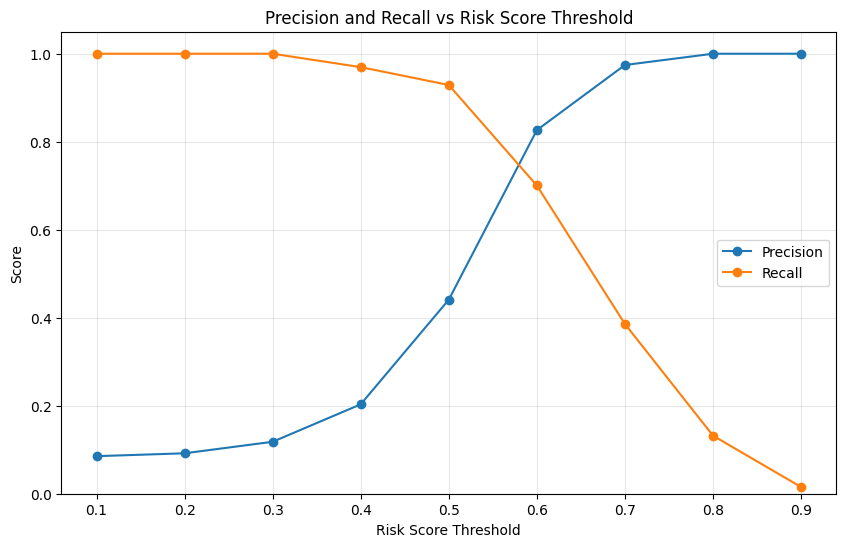

Threshold where Precision and Recall are closest:
-----------------------------------------------
Threshold : 0.6
Precision : 0.8263
Recall    : 0.7005
Difference: 0.1258


In [23]:
#Q22

import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score

# Make sure risk_score is numeric
eval_df["risk_score_clean"] = pd.to_numeric(
    eval_df["risk_score"],
    errors="coerce"
)

# Remove rows where risk_score is missing
threshold_df = eval_df.dropna(
    subset=["risk_score_clean"]
).copy()


# Calculate precision and recall for thresholds 0.1 to 0.9
thresholds = np.arange(0.1, 1.0, 0.1)

results = []

for threshold in thresholds:

    # Predict default if risk_score >= threshold
    predictions = (
        threshold_df["risk_score_clean"] >= threshold
    ).astype(int)

    precision_value = precision_score(
        threshold_df["actual_default_clean"],
        predictions,
        zero_division=0
    )

    recall_value = recall_score(
        threshold_df["actual_default_clean"],
        predictions,
        zero_division=0
    )

    results.append({
        "threshold": round(threshold, 1),
        "precision": precision_value,
        "recall": recall_value
    })


# Create the DataFrame
threshold_results = pd.DataFrame(results)


# Display results
print("Precision and Recall at Different Thresholds")
print("---------------------------------------------")

print(
    threshold_results[
        ["threshold", "precision", "recall"]
    ]
    .round(4)
    .to_string(index=False)
)


import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score

# ---------------------------------------------------------
# Make sure risk_score is numeric
# ---------------------------------------------------------

eval_df["risk_score_clean"] = pd.to_numeric(
    eval_df["risk_score"],
    errors="coerce"
)

# Remove rows where risk_score is missing
threshold_df = eval_df.dropna(
    subset=["risk_score_clean"]
).copy()


# ---------------------------------------------------------
# Calculate precision and recall for thresholds 0.1 to 0.9
# ---------------------------------------------------------

thresholds = np.arange(0.1, 1.0, 0.1)

results = []

for threshold in thresholds:

    # Predict default if risk_score >= threshold
    predictions = (
        threshold_df["risk_score_clean"] >= threshold
    ).astype(int)

    precision_value = precision_score(
        threshold_df["actual_default_clean"],
        predictions,
        zero_division=0
    )

    recall_value = recall_score(
        threshold_df["actual_default_clean"],
        predictions,
        zero_division=0
    )

    results.append({
        "threshold": round(threshold, 1),
        "precision": precision_value,
        "recall": recall_value
    })


# Create the DataFrame
threshold_results = pd.DataFrame(results)


# Display results# ---------------------------------------------------------

print("Precision and Recall at Different Thresholds")
print("---------------------------------------------")

print(
    threshold_results[
        ["threshold", "precision", "recall"]
    ]
    .round(4)
    .to_string(index=False)
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Risk Score Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Risk Score Threshold")

plt.xticks(thresholds)
plt.ylim(0, 1.05)

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()


threshold_results["difference"] = abs(
    threshold_results["precision"] -
    threshold_results["recall"]
)

closest = threshold_results.loc[
    threshold_results["difference"].idxmin()
]

print("Threshold where Precision and Recall are closest:")
print("-----------------------------------------------")
print("Threshold :", closest["threshold"])
print("Precision :", round(closest["precision"], 4))
print("Recall    :", round(closest["recall"], 4))
print(
    "Difference:",
    round(closest["difference"], 4)
)

